# 图像特征工程 (CS231n Assignment 1 Q4)

本笔记本对应 CS231n 课程 Assignment 1 的 Q4 部分，涵盖图像特征工程的核心技术：HOG（方向梯度直方图）、颜色直方图及其在图像分类中的应用。

## 学习路径

1. **直觉理解** - 为什么需要特征工程？原始像素的局限性
2. **手动计算** - 在小图像块上手动计算 HOG 和颜色直方图
3. **代码实现** - 使用 NumPy 从零实现 HOG 和颜色直方图提取
4. **实验观察** - 对比不同特征在分类任务上的表现

## 对应课程内容

- Lecture 5: Loss Functions and Optimization
- Lecture 6: Introduction to Neural Networks
- Assignment 1 Q4: Image Features and Training Neural Nets


## 目录

- [1. 直觉理解](#1-直觉理解)
- [2. 手动计算](#2-手动计算)
- [3. 代码实现](#3-代码实现)
- [4. 实验观察](#4-实验观察)
- [5. 课后作业](#5-课后作业)
- [6. 参考文献与作业解答](#6-参考文献与作业解答)


## 1. 直觉理解

### 1.1 为什么需要特征工程

在深度学习普及之前，**特征工程**是计算机视觉的核心任务。即使在使用神经网络时，理解特征工程仍然重要，因为它帮助我们理解：

- 图像中什么信息是有用的
- 如何从原始像素中提取有意义的表示
- 为什么卷积神经网络能自动学习到类似 HOG 的特征

**原始像素的问题：**
- 像素值对光照变化极其敏感
- 物体的位置变化会导致特征完全不同
- 维度高（32x32x3 = 3072维），但信息密度低
- 相邻像素高度相关，存在大量冗余

**好的特征应该具备：**
- **平移不变性**：物体位置变化不影响特征
- **光照不变性**：亮度变化不影响特征
- **尺度不变性**：物体大小变化不影响特征
- **判别性**：不同类别的特征应该有明显差异


### 1.2 原始像素 vs 工程特征

**原始像素分类器的局限：**

假设我们用 kNN 分类器在 CIFAR-10 上分类：
- 使用原始像素：准确率约 15-25%（略好于随机猜测的 10%）
- 使用 HOG + 颜色直方图：准确率可提升到 40-50%

**特征工程的优势：**
- 降维：从 3072 维降到几百维
- 更好的判别性：提取边缘、纹理等结构信息
- 部分不变性：对光照、平移有一定鲁棒性

**特征工程的局限：**
- 需要领域知识
- 难以处理复杂的语义信息
- 最终被端到端学习（CNN）所取代

即便如此，理解特征工程对理解 CNN 的工作原理至关重要。


### 1.3 HOG 特征：方向梯度直方图

HOG（Histogram of Oriented Gradients）是计算机视觉中最经典的手工特征之一，由 Dalal 和 Triggs 在 2005 年提出。

**核心思想：**
- 物体的形状可以通过边缘方向来描述
- 将图像分成小区域（cells），在每个区域内统计边缘方向分布
- 局部归一化提高对光照变化的鲁棒性

**HOG 特征提取流程：**
1. 图像预处理（灰度化、归一化）
2. 计算梯度（水平、垂直方向）
3. 计算梯度幅值和方向
4. 将图像分成 cells（如 8x8 像素）
5. 在每个 cell 内建立方向直方图（如 9 个 bin，0-180度）
6. 将相邻 cells 组成 blocks（如 2x2 cells）
7. 对每个 block 进行 L2 归一化
8. 拼接所有 block 的直方图形成最终特征向量

**为什么 HOG 有效？**
- 梯度捕捉了边缘信息，边缘是物体形状的关键描述
- 直方图统计提供了局部区域的概要信息
- 归一化减少了光照变化的影响


### 1.4 颜色直方图特征

颜色直方图是另一种简单但有效的图像特征。

**核心思想：**
- 不同类别的物体往往有不同的颜色分布
- 颜色直方图统计图像中各种颜色的出现频率
- 对物体位置和旋转变化具有不变性

**实现方法：**
1. 将 RGB 颜色空间量化到较少的 bin（如每个通道 4 个 bin）
2. 统计每个 bin 的像素数量
3. 归一化为概率分布

**特征维度：**
- 如果每个通道 4 个 bin，则总维度 = 4 x 4 x 4 = 64 维
- 或者分别对每个通道做直方图，总维度 = 4 + 4 + 4 = 12 维

**颜色直方图的局限：**
- 丢失了空间信息（不同颜色排列的图像可能有相同的直方图）
- 对颜色相似但形状不同的类别区分能力弱

**解决方案：** 将 HOG 和颜色直方图结合使用，互补优势。


In [7]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully!")
print(f"NumPy version: {np.__version__}")


Libraries loaded successfully!
NumPy version: 2.2.6


## 2. 手动计算

### 2.1 HOG 手动计算：梯度计算

让我们在一个 4x4 的小图像块上手动计算 HOG 特征。

**步骤1：计算梯度**

使用简单的 [-1, 0, 1] 滤波器：
- 水平梯度 gx：左右相邻像素的差
- 垂直梯度 gy：上下相邻像素的差

对于 4x4 的图像块，边缘像素用 0 填充：

    原始图像块 I:
    [10, 20, 30, 40]
    [15, 25, 35, 45]
    [20, 30, 40, 50]
    [25, 35, 45, 55]

**计算 gx（水平梯度）：**
对于像素 (0,0)：gx = I[0,1] - I[0,0] = 20 - 10 = 10
对于像素 (0,1)：gx = I[0,2] - I[0,0] = 30 - 10 = 20（使用中心差分）
...

**计算 gy（垂直梯度）：**
对于像素 (0,0)：gy = I[1,0] - I[0,0] = 15 - 10 = 5
...


In [9]:
# Manual HOG: Step 1 - Gradient computation on a 4x4 patch

# Define a simple 4x4 image patch
patch = np.array([
    [10, 20, 30, 40],
    [15, 25, 35, 45],
    [20, 30, 40, 50],
    [25, 35, 45, 55]
], dtype=float)

print("Original 4x4 patch:")
print(patch)

# Compute horizontal gradient (gx) using [-1, 0, 1] filter
# Pad with zeros on left and right
gx = np.zeros_like(patch)
for i in range(patch.shape[0]):
    for j in range(patch.shape[1]):
        left = patch[i, j-1] if j > 0 else 0
        right = patch[i, j+1] if j < patch.shape[1]-1 else 0
        gx[i, j] = right - left

print(f"\nHorizontal gradient (gx):")
print(gx)

# Compute vertical gradient (gy) using [-1, 0, 1] filter
gy = np.zeros_like(patch)
for i in range(patch.shape[0]):
    for j in range(patch.shape[1]):
        top = patch[i-1, j] if i > 0 else 0
        bottom = patch[i+1, j] if i < patch.shape[0]-1 else 0
        gy[i, j] = bottom - top

print(f"\nVertical gradient (gy):")
print(gy)

# Compute gradient magnitude and orientation
magnitude = np.sqrt(gx**2 + gy**2)
orientation = np.degrees(np.arctan2(gy, gx))  # Convert to degrees
orientation = orientation % 180  # Wrap to [0, 180)

print(f"\nGradient magnitude:")
print(magnitude)
print(f"\nGradient orientation (degrees, [0, 180)):")
print(orientation)


Original 4x4 patch:
[[10. 20. 30. 40.]
 [15. 25. 35. 45.]
 [20. 30. 40. 50.]
 [25. 35. 45. 55.]]

Horizontal gradient (gx):
[[ 20.  20.  20. -30.]
 [ 25.  20.  20. -35.]
 [ 30.  20.  20. -40.]
 [ 35.  20.  20. -45.]]

Vertical gradient (gy):
[[ 15.  25.  35.  45.]
 [ 10.  10.  10.  10.]
 [ 10.  10.  10.  10.]
 [-20. -30. -40. -50.]]

Gradient magnitude:
[[25.         32.01562119 40.31128874 54.08326913]
 [26.92582404 22.36067977 22.36067977 36.40054945]
 [31.6227766  22.36067977 22.36067977 41.23105626]
 [40.31128874 36.05551275 44.72135955 67.26812024]]

Gradient orientation (degrees, [0, 180)):
[[ 36.86989765  51.34019175  60.2551187  123.69006753]
 [ 21.80140949  26.56505118  26.56505118 164.0546041 ]
 [ 18.43494882  26.56505118  26.56505118 165.96375653]
 [150.2551187  123.69006753 116.56505118  48.0127875 ]]


### 2.2 HOG 手动计算：直方图分箱

**步骤2：构建方向直方图**

将整个 4x4 patch 作为一个 cell，建立 9 个方向 bin（每个 20 度）：
- bin 0: [0, 20) 度
- bin 1: [20, 40) 度
- ...
- bin 8: [160, 180) 度

对于每个像素：
- 根据其梯度方向确定属于哪个 bin
- 将其梯度幅值累加到对应 bin

**双线性插值（简化版）：**
标准 HOG 使用双线性插值将幅值分配到相邻的两个 bin。这里我们使用简化版：将全部幅值分配到最近的 bin。

**步骤3：L2 归一化**
    histogram = histogram / sqrt(sum(histogram^2) + epsilon)

这个归一化步骤使得特征对光照变化更鲁棒。


In [11]:
# Manual HOG: Step 2 - Build orientation histogram

# Define 9 bins for [0, 180) degrees
num_bins = 9
bin_edges = np.linspace(0, 180, num_bins + 1)
histogram = np.zeros(num_bins)

print("Bin edges (degrees):")
for i in range(num_bins):
    print(f"  Bin {i}: [{bin_edges[i]:.0f}, {bin_edges[i+1]:.0f})")

# Accumulate magnitudes into bins
for i in range(patch.shape[0]):
    for j in range(patch.shape[1]):
        angle = orientation[i, j]
        mag = magnitude[i, j]
        
        # Find which bin this angle belongs to
        bin_idx = int(angle / 20) % num_bins
        histogram[bin_idx] += mag

print(f"\nOrientation histogram (before normalization):")
for i in range(num_bins):
    print(f"  Bin {i} ({bin_edges[i]:.0f}-{bin_edges[i+1]:.0f} deg): {histogram[i]:.2f}")

# L2 normalization
epsilon = 1e-5
norm = np.sqrt(np.sum(histogram**2) + epsilon)
histogram_normalized = histogram / norm

print(f"\nNormalized histogram:")
for i in range(num_bins):
    bar = '#' * int(histogram_normalized[i] * 50)
    print(f"  Bin {i}: {histogram_normalized[i]:.4f} |{bar}")

print(f"\nL2 norm of original histogram: {np.linalg.norm(histogram):.4f}")
print(f"L2 norm of normalized histogram: {np.linalg.norm(histogram_normalized):.4f}")


Bin edges (degrees):
  Bin 0: [0, 20)
  Bin 1: [20, 40)
  Bin 2: [40, 60)
  Bin 3: [60, 80)
  Bin 4: [80, 100)
  Bin 5: [100, 120)
  Bin 6: [120, 140)
  Bin 7: [140, 160)
  Bin 8: [160, 180)

Orientation histogram (before normalization):
  Bin 0 (0-20 deg): 31.62
  Bin 1 (20-40 deg): 141.37
  Bin 2 (40-60 deg): 99.28
  Bin 3 (60-80 deg): 40.31
  Bin 4 (80-100 deg): 0.00
  Bin 5 (100-120 deg): 44.72
  Bin 6 (120-140 deg): 90.14
  Bin 7 (140-160 deg): 40.31
  Bin 8 (160-180 deg): 77.63

Normalized histogram:
  Bin 0: 0.1411 |#######
  Bin 1: 0.6307 |###############################
  Bin 2: 0.4429 |######################
  Bin 3: 0.1798 |########
  Bin 4: 0.0000 |
  Bin 5: 0.1995 |#########
  Bin 6: 0.4021 |####################
  Bin 7: 0.1798 |########
  Bin 8: 0.3463 |#################

L2 norm of original histogram: 224.1517
L2 norm of normalized histogram: 1.0000


### 2.3 颜色直方图手动计算

让我们在一个 4x4 的 RGB 图像上手动计算颜色直方图。

**方法：独立通道直方图**

将每个通道（R, G, B）的值域 [0, 255] 分成 4 个 bin：
- bin 0: [0, 64)
- bin 1: [64, 128)
- bin 2: [128, 192)
- bin 3: [192, 256)

对每个通道独立统计，得到 3x4 = 12 维特征。

**示例图像块：**
    R 通道: [[100, 150, 200, 50], ...]
    G 通道: [[50, 100, 150, 200], ...]
    B 通道: [[200, 50, 100, 150], ...]

统计每个通道各 bin 的像素数量，然后归一化。


In [13]:
# Manual color histogram calculation

# Create a small 4x4 RGB image patch
np.random.seed(42)
color_patch = np.random.randint(0, 256, size=(4, 4, 3))

print("4x4 RGB image patch:")
print(f"R channel:\n{color_patch[:,:,0]}")
print(f"G channel:\n{color_patch[:,:,1]}")
print(f"B channel:\n{color_patch[:,:,2]}")

# Define color histogram parameters
num_color_bins = 4
bin_size = 256 // num_color_bins  # 64

# Compute color histogram for each channel
color_hist = np.zeros((3, num_color_bins))

for ch in range(3):  # R, G, B
    channel = color_patch[:, :, ch]
    for b in range(num_color_bins):
        low = b * bin_size
        high = (b + 1) * bin_size
        color_hist[ch, b] = np.sum((channel >= low) & (channel < high))

print(f"\nColor histogram (before normalization):")
channel_names = ['R', 'G', 'B']
for ch in range(3):
    print(f"  {channel_names[ch]} channel: {color_hist[ch].astype(int)}")

# Normalize each channel independently
color_hist_normalized = color_hist / color_patch.shape[0] / color_patch.shape[1]

print(f"\nNormalized color histogram:")
for ch in range(3):
    print(f"  {channel_names[ch]} channel: {color_hist_normalized[ch]}")

# Flatten to feature vector
color_feature = color_hist_normalized.flatten()
print(f"\nFlattened color feature ({len(color_feature)} dim):")
print(color_feature)


4x4 RGB image patch:
R channel:
[[102  14 188 121]
 [ 74 116 151  52]
 [235 129  20  57]
 [235 218 169 187]]
G channel:
[[179 106  20 210]
 [202  99 130   1]
 [157 191 160  21]
 [ 88  58 255 207]]
B channel:
[[ 92  71 102 214]
 [ 87 103 149  87]
 [ 37 187 203 252]
 [ 48 254 219  14]]

Color histogram (before normalization):
  R channel: [4 4 5 3]
  G channel: [4 3 5 4]
  B channel: [3 6 2 5]

Normalized color histogram:
  R channel: [0.25   0.25   0.3125 0.1875]
  G channel: [0.25   0.1875 0.3125 0.25  ]
  B channel: [0.1875 0.375  0.125  0.3125]

Flattened color feature (12 dim):
[0.25   0.25   0.3125 0.1875 0.25   0.1875 0.3125 0.25   0.1875 0.375
 0.125  0.3125]


## 3. 代码实现

### 3.1 HOG 特征实现

我们将从零实现一个完整的 HOG 特征提取器。

**实现参数：**
- cell_size: 8x8 像素
- block_size: 2x2 cells
- num_bins: 9（0-180度，每个 bin 20度）
- 使用双线性插值分配梯度幅值

**完整流程：**
1. 灰度化（如果输入是彩色图像）
2. 计算梯度
3. 在每个 cell 内构建方向直方图
4. 将 cells 组成 blocks 并归一化
5. 拼接所有 block 特征


In [15]:
def compute_gradients(image):
    """
    Compute image gradients using [-1, 0, 1] filter.
    
    Input:
    - image: 2D array (grayscale) of shape (H, W)
    
    Returns:
    - gx: horizontal gradient, shape (H, W)
    - gy: vertical gradient, shape (H, W)
    """
    # Pad image with zeros
    padded = np.pad(image, 1, mode='edge')
    
    # Compute gradients using simple difference
    gx = padded[1:-1, 2:] - padded[1:-1, :-2]
    gy = padded[2:, 1:-1] - padded[:-2, 1:-1]
    
    return gx, gy

# Test gradient computation
test_img = np.array([
    [10, 20, 30, 40],
    [15, 25, 35, 45],
    [20, 30, 40, 50],
    [25, 35, 45, 55]
], dtype=float)

gx, gy = compute_gradients(test_img)
print(f"Image shape: {test_img.shape}")
print(f"Gradient gx shape: {gx.shape}")
print(f"Gradient gy shape: {gy.shape}")
print(f"\ngx:\n{gx}")
print(f"\ngy:\n{gy}")


Image shape: (4, 4)
Gradient gx shape: (4, 4)
Gradient gy shape: (4, 4)

gx:
[[10. 20. 20. 10.]
 [10. 20. 20. 10.]
 [10. 20. 20. 10.]
 [10. 20. 20. 10.]]

gy:
[[ 5.  5.  5.  5.]
 [10. 10. 10. 10.]
 [10. 10. 10. 10.]
 [ 5.  5.  5.  5.]]


In [16]:
def compute_hog_cell(gx_cell, gy_cell, num_bins=9):
    """
    Compute orientation histogram for a single cell.
    
    Inputs:
    - gx_cell: horizontal gradient for the cell, shape (cell_h, cell_w)
    - gy_cell: vertical gradient for the cell, shape (cell_h, cell_w)
    - num_bins: number of orientation bins
    
    Returns:
    - hist: orientation histogram of shape (num_bins,)
    """
    # Compute magnitude and orientation
    magnitude = np.sqrt(gx_cell**2 + gy_cell**2)
    orientation = np.degrees(np.arctan2(gy_cell, gx_cell))
    orientation = orientation % 180  # Wrap to [0, 180)
    
    # Bin width
    bin_width = 180.0 / num_bins
    
    # Initialize histogram
    hist = np.zeros(num_bins)
    
    # Bilinear interpolation: distribute magnitude to adjacent bins
    for i in range(magnitude.shape[0]):
        for j in range(magnitude.shape[1]):
            angle = orientation[i, j]
            mag = magnitude[i, j]
            
            # Find the two adjacent bins
            bin_pos = angle / bin_width
            bin_low = int(np.floor(bin_pos)) % num_bins
            bin_high = (bin_low + 1) % num_bins
            weight_high = bin_pos - np.floor(bin_pos)
            weight_low = 1 - weight_high
            
            hist[bin_low] += mag * weight_low
            hist[bin_high] += mag * weight_high
    
    return hist

# Test on a small cell
gx_cell = gx[:4, :4]
gy_cell = gy[:4, :4]
cell_hist = compute_hog_cell(gx_cell, gy_cell, num_bins=9)
print(f"Cell histogram: {cell_hist}")
print(f"Sum of histogram: {np.sum(cell_hist):.2f}")
print(f"Max bin: {np.argmax(cell_hist)} (value={np.max(cell_hist):.2f})")


Cell histogram: [ 24.58919811 147.99729093  86.46610899  14.14213562   0.
   0.           0.           0.           0.        ]
Sum of histogram: 273.19
Max bin: 1 (value=148.00)


In [17]:
def extract_hog_features(image, cell_size=8, block_size=2, num_bins=9):
    """
    Extract HOG features from an image.
    
    Inputs:
    - image: 2D array (grayscale) or 3D array (RGB), shape (H, W) or (H, W, 3)
    - cell_size: size of each cell in pixels
    - block_size: number of cells per block (in each dimension)
    - num_bins: number of orientation bins
    
    Returns:
    - hog_features: 1D array of HOG features
    """
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        image = np.mean(image, axis=2)
    
    H, W = image.shape
    
    # Compute gradients
    gx, gy = compute_gradients(image)
    
    # Number of cells in each dimension
    n_cells_y = H // cell_size
    n_cells_x = W // cell_size
    
    # Crop gradients to fit cells
    crop_h = n_cells_y * cell_size
    crop_w = n_cells_x * cell_size
    gx = gx[:crop_h, :crop_w]
    gy = gy[:crop_h, :crop_w]
    
    # Compute cell histograms
    cell_hists = np.zeros((n_cells_y, n_cells_x, num_bins))
    for i in range(n_cells_y):
        for j in range(n_cells_x):
            start_i = i * cell_size
            start_j = j * cell_size
            gx_cell = gx[start_i:start_i+cell_size, start_j:start_j+cell_size]
            gy_cell = gy[start_i:start_i+cell_size, start_j:start_j+cell_size]
            cell_hists[i, j] = compute_hog_cell(gx_cell, gy_cell, num_bins)
    
    # Compute block histograms with normalization
    n_blocks_y = n_cells_y - block_size + 1
    n_blocks_x = n_cells_x - block_size + 1
    block_dim = block_size * block_size * num_bins
    
    hog_features = np.zeros(n_blocks_y * n_blocks_x * block_dim)
    epsilon = 1e-5
    idx = 0
    
    for i in range(n_blocks_y):
        for j in range(n_blocks_x):
            # Extract block
            block = cell_hists[i:i+block_size, j:j+block_size, :].flatten()
            # L2 normalize
            norm = np.sqrt(np.sum(block**2) + epsilon)
            block = block / norm
            hog_features[idx:idx+block_dim] = block
            idx += block_dim
    
    return hog_features

# Test HOG extraction
np.random.seed(42)
test_image = np.random.randint(0, 256, size=(32, 32, 3), dtype=np.uint8)
hog_feat = extract_hog_features(test_image, cell_size=8, block_size=2, num_bins=9)
print(f"Input image shape: {test_image.shape}")
print(f"HOG feature dimension: {hog_feat.shape[0]}")
print(f"Expected dimension: {(32//8-1) * (32//8-1) * 2*2*9} = {(32//8-1)*(32//8-1)*2*2*9}")
print(f"Feature stats: min={hog_feat.min():.4f}, max={hog_feat.max():.4f}, mean={hog_feat.mean():.4f}")


Input image shape: (32, 32, 3)
HOG feature dimension: 324
Expected dimension: 324 = 324
Feature stats: min=0.0507, max=0.3370, mean=0.1578


### 3.2 颜色直方图实现

颜色直方图实现相对简单。我们对每个通道独立计算直方图，然后拼接成特征向量。

**实现选项：**
1. 独立通道直方图（3 x num_bins 维）
2. 联合 3D 直方图（num_bins^3 维）

我们实现两种方法，并使用独立通道版本作为主要特征。


In [19]:
def extract_color_histogram(image, num_bins=8):
    """
    Extract color histogram features from an RGB image.
    
    Inputs:
    - image: 3D array (RGB), shape (H, W, 3)
    - num_bins: number of bins per channel
    
    Returns:
    - feature: 1D array of color histogram features (3 * num_bins)
    """
    H, W, C = image.shape
    feature = np.zeros(C * num_bins)
    bin_size = 256 / num_bins
    
    for ch in range(C):
        channel = image[:, :, ch].astype(float)
        hist, _ = np.histogram(channel, bins=num_bins, range=(0, 256))
        # Normalize
        feature[ch*num_bins:(ch+1)*num_bins] = hist / (H * W)
    
    return feature

def extract_color_histogram_3d(image, num_bins=4):
    """
    Extract 3D joint color histogram.
    
    Returns:
    - feature: 1D array of shape (num_bins^3,)
    """
    H, W, C = image.shape
    bin_size = 256 / num_bins
    
    # Quantize each channel
    quantized = np.minimum(image.astype(float) // bin_size, num_bins - 1).astype(int)
    
    # Create 3D histogram
    hist = np.zeros((num_bins, num_bins, num_bins))
    for i in range(H):
        for j in range(W):
            r, g, b = quantized[i, j]
            hist[r, g, b] += 1
    
    # Normalize
    hist = hist / (H * W)
    return hist.flatten()

# Test color histogram extraction
np.random.seed(42)
test_image = np.random.randint(0, 256, size=(32, 32, 3), dtype=np.uint8)

# Method 1: Independent channel histograms
feat_indep = extract_color_histogram(test_image, num_bins=8)
print(f"Independent channel histogram: {feat_indep.shape[0]} dims")
print(f"Feature (first 24): {feat_indep[:24]}")

# Method 2: 3D joint histogram
feat_3d = extract_color_histogram_3d(test_image, num_bins=4)
print(f"\n3D joint histogram: {feat_3d.shape[0]} dims")
print(f"Feature (first 16): {feat_3d[:16]}")


Independent channel histogram: 24 dims
Feature (first 24): [0.13476562 0.11425781 0.12988281 0.11816406 0.12207031 0.12890625
 0.11328125 0.13867188 0.14453125 0.13085938 0.10351562 0.11914062
 0.13085938 0.140625   0.1171875  0.11328125 0.12207031 0.12890625
 0.15234375 0.12011719 0.10742188 0.11523438 0.11621094 0.13769531]

3D joint histogram: 64 dims
Feature (first 16): [0.01660156 0.02050781 0.01367188 0.01855469 0.0078125  0.01171875
 0.01660156 0.01855469 0.01855469 0.01855469 0.01367188 0.01269531
 0.01855469 0.01855469 0.01171875 0.01269531]


### 3.3 特征提取管道

我们将不同特征提取方法整合到一个统一的管道中。

**管道流程：**
1. 输入图像
2. 选择特征类型（raw / hog / color / combined）
3. 提取特征
4. 返回特征向量

**combined 特征** 将 HOG 和颜色直方图拼接，利用两者的互补优势。


In [21]:
def extract_features(images, feature_type='hog', 
                          cell_size=8, block_size=2, hog_bins=9,
                          color_bins=8):
    """
    Extract features from a batch of images.
    
    Inputs:
    - images: array of shape (N, H, W, 3)
    - feature_type: 'raw', 'hog', 'color', or 'combined'
    
    Returns:
    - features: array of shape (N, D) where D depends on feature_type
    """
    N = images.shape[0]
    
    if feature_type == 'raw':
        # Flatten raw pixels
        features = images.reshape(N, -1).astype(float) / 255.0
        return features
    
    # For other features, compute per image
    all_features = []
    for i in range(N):
        img = images[i]
        
        if feature_type == 'hog':
            feat = extract_hog_features(img, cell_size, block_size, hog_bins)
        elif feature_type == 'color':
            feat = extract_color_histogram(img, color_bins)
        elif feature_type == 'combined':
            hog_feat = extract_hog_features(img, cell_size, block_size, hog_bins)
            color_feat = extract_color_histogram(img, color_bins)
            # Normalize each part before concatenation
            hog_feat = hog_feat / (np.linalg.norm(hog_feat) + 1e-8)
            color_feat = color_feat / (np.linalg.norm(color_feat) + 1e-8)
            feat = np.concatenate([hog_feat, color_feat])
        else:
            raise ValueError(f"Unknown feature type: {feature_type}")
        
        all_features.append(feat)
    
    return np.array(all_features)

print("Feature extraction pipeline defined!")
print("Available feature types: 'raw', 'hog', 'color', 'combined'")


Feature extraction pipeline defined!
Available feature types: 'raw', 'hog', 'color', 'combined'


### 3.4 kNN 分类器

我们实现一个简单的 k 近邻（kNN）分类器来评估不同特征的效果。

**kNN 算法：**
1. 计算测试样本与所有训练样本的距离
2. 找到 k 个最近的训练样本
3. 投票决定类别

我们使用 L2 距离（欧氏距离）。


In [23]:
class KNNClassifier:
    """Simple k-Nearest Neighbors classifier."""
    
    def __init__(self, k=5):
        self.k = k
    
    def fit(self, X_train, y_train):
        """Store training data."""
        self.X_train = X_train
        self.y_train = y_train
    
    def predict(self, X_test):
        """Predict labels for test data."""
        N_test = X_test.shape[0]
        N_train = self.X_train.shape[0]
        
        # Compute L2 distances (vectorized)
        # dist[i,j] = ||X_test[i] - X_train[j]||^2
        # = ||X_test[i]||^2 + ||X_train[j]||^2 - 2 * X_test[i] . X_train[j]
        dists = np.zeros((N_test, N_train))
        test_sq = np.sum(X_test**2, axis=1).reshape(-1, 1)
        train_sq = np.sum(self.X_train**2, axis=1).reshape(1, -1)
        cross = X_test @ self.X_train.T
        dists = np.sqrt(np.maximum(test_sq + train_sq - 2 * cross, 0))
        
        # Find k nearest neighbors and vote
        predictions = np.zeros(N_test, dtype=int)
        for i in range(N_test):
            nearest_indices = np.argsort(dists[i])[:self.k]
            nearest_labels = self.y_train[nearest_indices]
            predictions[i] = np.bincount(nearest_labels).argmax()
        
        return predictions
    
    def score(self, X_test, y_test):
        """Compute classification accuracy."""
        pred = self.predict(X_test)
        return np.mean(pred == y_test)

# Test kNN
np.random.seed(42)
X_dummy = np.random.randn(100, 10)
y_dummy = np.random.randint(0, 3, 100)
knn = KNNClassifier(k=5)
knn.fit(X_dummy[:80], y_dummy[:80])
acc = knn.score(X_dummy[80:], y_dummy[80:])
print(f"Dummy test accuracy: {acc:.4f}")
print("kNN classifier ready!")


Dummy test accuracy: 0.4500
kNN classifier ready!


## 4. 实验观察

### 4.1 合成图像数据集

我们创建一个合成图像数据集来测试不同特征的效果。数据集包含三类简单形状：
- **圆形**
- **方形**  
- **三角形**

每个形状有不同颜色和位置变化，图像大小为 32x32x3。

**为什么使用合成数据？**
- 可以控制变量（形状、颜色、位置）
- 便于理解特征的作用
- 可重现实验结果


In [25]:
def create_shape_image(shape='circle', color=None, img_size=32, seed=None):
    """Create a synthetic image with a specific shape."""
    if seed is not None:
        np.random.seed(seed)
    
    if color is None:
        color = np.random.randint(50, 200, size=3)
    
    # Background: random gray
    bg = np.random.randint(180, 220)
    img = np.ones((img_size, img_size, 3), dtype=np.uint8) * bg
    
    # Add noise to background
    noise = np.random.randint(-15, 15, size=(img_size, img_size, 3))
    img = np.clip(img.astype(int) + noise, 0, 255).astype(np.uint8)
    
    # Draw shape
    cx, cy = img_size // 2, img_size // 2
    size = np.random.randint(8, 14)
    
    if shape == 'circle':
        for i in range(img_size):
            for j in range(img_size):
                if (i - cx)**2 + (j - cy)**2 <= size**2:
                    img[i, j] = color
    elif shape == 'square':
        img[cx-size:cx+size, cy-size:cy+size] = color
    elif shape == 'triangle':
        for i in range(img_size):
            for j in range(img_size):
                # Triangle: y >= cx - |x - cy| (pointing up)
                if i >= cx and abs(j - cy) <= (i - cx) and (i - cx) <= size:
                    img[i, j] = color
    
    return img

def generate_synthetic_dataset(n_per_class=50, img_size=32, seed=42):
    """Generate synthetic shape dataset."""
    np.random.seed(seed)
    shapes = ['circle', 'square', 'triangle']
    
    images = []
    labels = []
    
    for class_idx, shape in enumerate(shapes):
        for _ in range(n_per_class):
            img = create_shape_image(shape, img_size=img_size, 
                                     seed=np.random.randint(0, 100000))
            images.append(img)
            labels.append(class_idx)
    
    images = np.array(images)
    labels = np.array(labels)
    
    # Shuffle
    idx = np.random.permutation(len(images))
    images, labels = images[idx], labels[idx]
    
    return images, labels

# Generate dataset
images, labels = generate_synthetic_dataset(n_per_class=60, img_size=32, seed=42)
print(f"Dataset shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Classes: {np.unique(labels)}")
print(f"Samples per class: {np.bincount(labels)}")


Dataset shape: (180, 32, 32, 3)
Labels shape: (180,)
Classes: [0 1 2]
Samples per class: [60 60 60]


Dataset visualization saved!


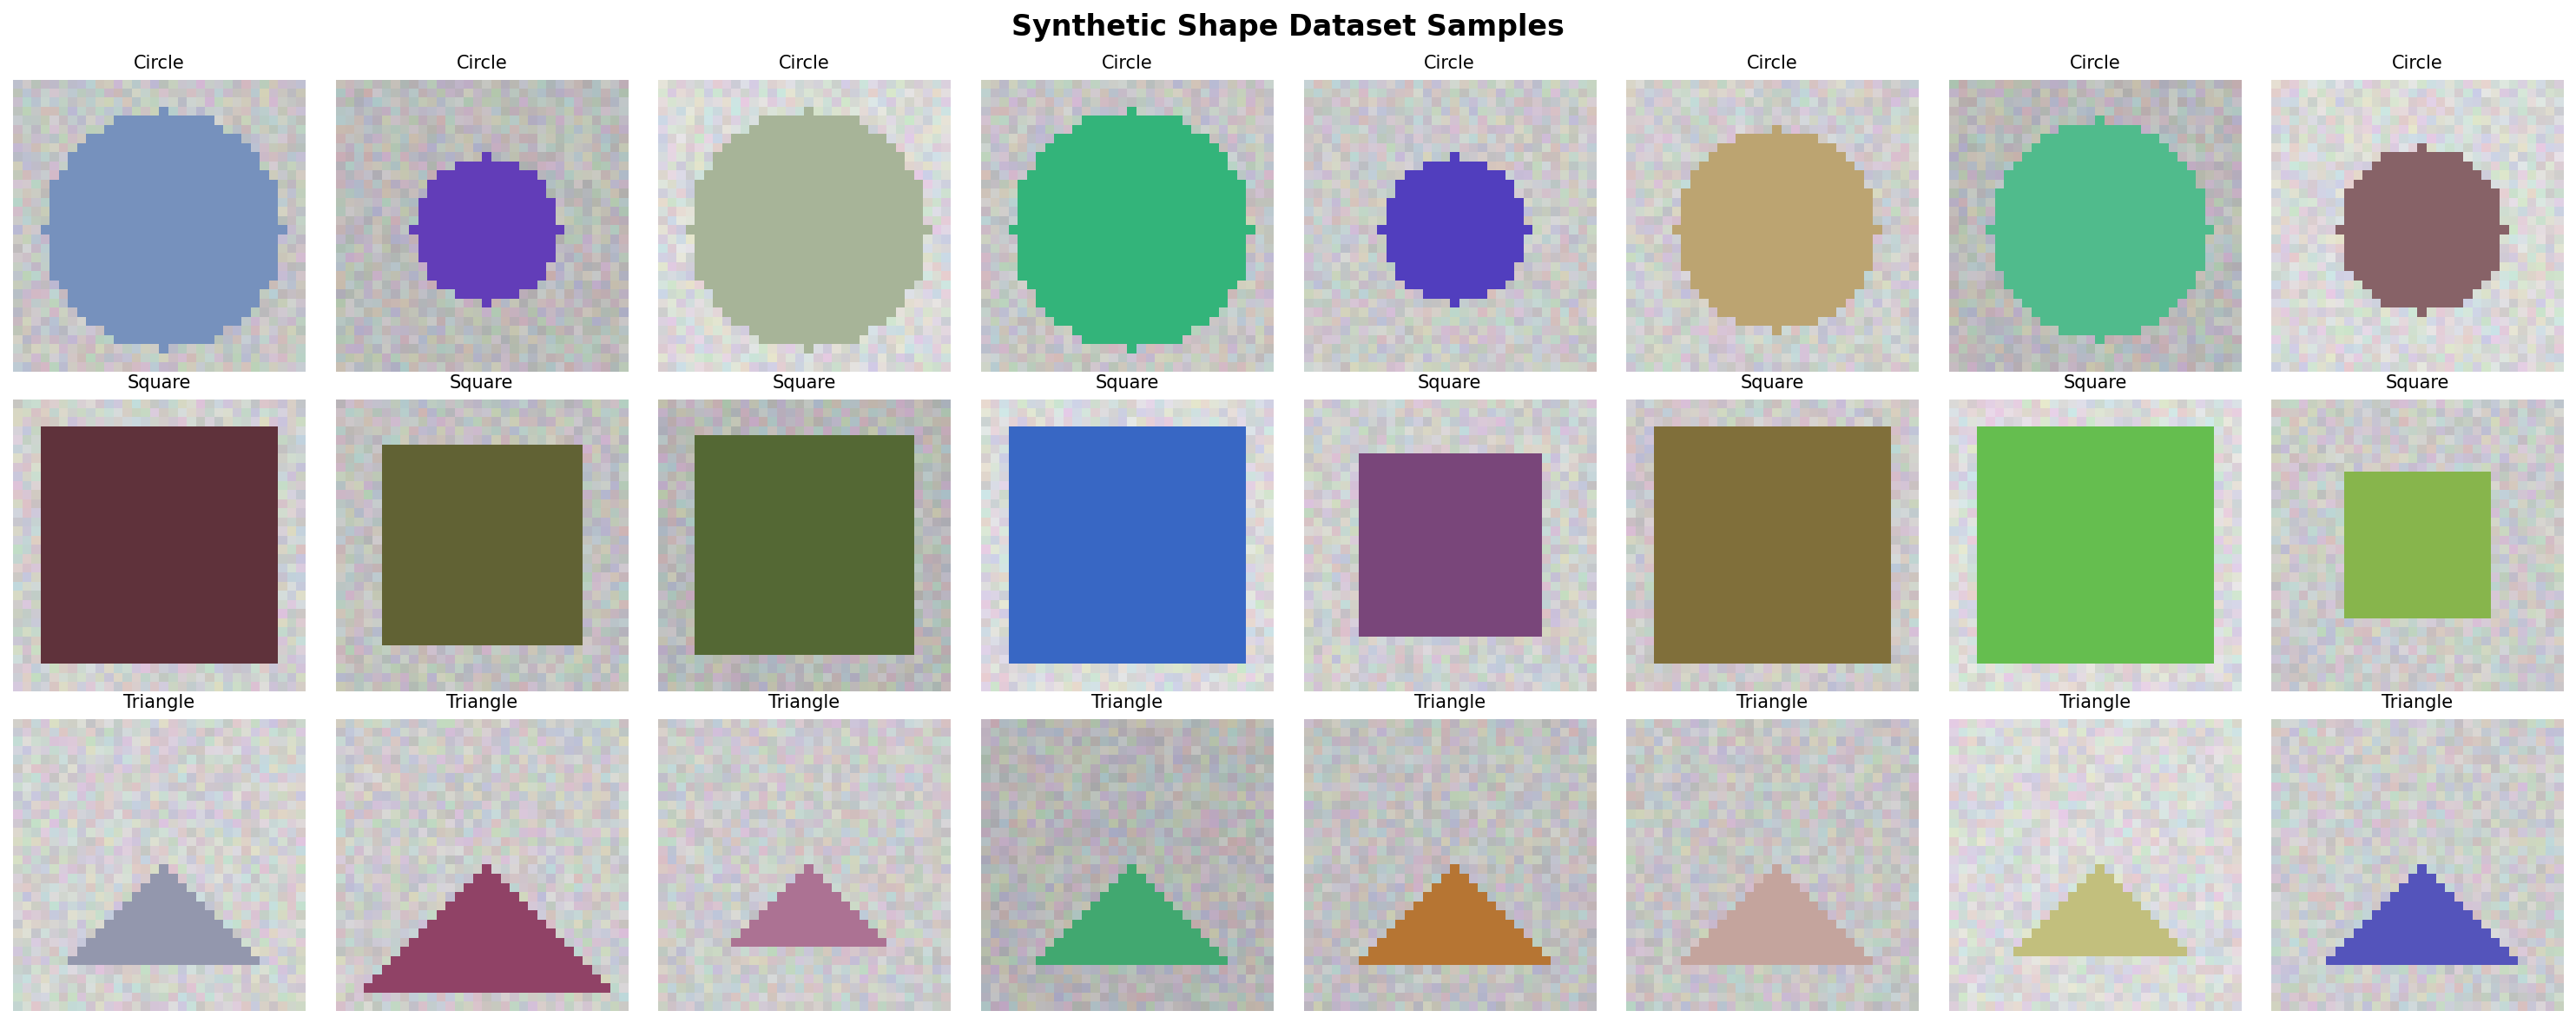

In [26]:
# Visualize sample images from the dataset
fig, axes = plt.subplots(3, 8, figsize=(20, 8))
shape_names = ['Circle', 'Square', 'Triangle']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for class_idx in range(3):
    class_images = images[labels == class_idx]
    for j in range(8):
        ax = axes[class_idx, j]
        ax.imshow(class_images[j])
        ax.set_title(f'{shape_names[class_idx]}', fontsize=10)
        ax.axis('off')

plt.suptitle('Synthetic Shape Dataset Samples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('synthetic_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dataset visualization saved!")


### 4.2 提取不同特征

我们对整个数据集提取四种不同的特征表示，并对比它们的维度和统计特性。

**四种特征：**
1. **raw**: 原始像素（32x32x3 = 3072 维）
2. **hog**: HOG 特征（约 324 维）
3. **color**: 颜色直方图（24 维）
4. **combined**: HOG + 颜色直方图（约 348 维）


In [28]:
# Split dataset into train and test
np.random.seed(42)
n_total = len(images)
indices = np.random.permutation(n_total)
split = int(0.7 * n_total)
train_idx, test_idx = indices[:split], indices[split:]

X_train_img = images[train_idx]
y_train = labels[train_idx]
X_test_img = images[test_idx]
y_test = labels[test_idx]

print(f"Training set: {X_train_img.shape}")
print(f"Test set: {X_test_img.shape}")

# Extract different features
feature_types = ['raw', 'hog', 'color', 'combined']
features_train = {}
features_test = {}

for ftype in feature_types:
    print(f"\nExtracting {ftype} features...")
    features_train[ftype] = extract_features(X_train_img, feature_type=ftype)
    features_test[ftype] = extract_features(X_test_img, feature_type=ftype)
    print(f"  Train shape: {features_train[ftype].shape}")
    print(f"  Test shape: {features_test[ftype].shape}")
    print(f"  Feature range: [{features_train[ftype].min():.4f}, {features_train[ftype].max():.4f}]")


Training set: (125, 32, 32, 3)
Test set: (55, 32, 32, 3)

Extracting raw features...
  Train shape: (125, 3072)
  Test shape: (55, 3072)
  Feature range: [0.1961, 0.9137]

Extracting hog features...
  Train shape: (125, 324)
  Test shape: (55, 324)
  Feature range: [0.0000, 0.9487]

Extracting color features...
  Train shape: (125, 24)
  Test shape: (55, 24)
  Feature range: [0.0000, 0.9648]

Extracting combined features...
  Train shape: (125, 348)
  Test shape: (55, 348)
  Feature range: [0.0000, 0.6922]


### 4.3 分类性能对比

我们使用 kNN 分类器在不同特征上评估分类准确率。

**实验设计：**
- 分类器：kNN（k=5）
- 特征：raw, hog, color, combined
- 评估指标：准确率
- 对比：不同特征的准确率差异

**预期结果：**
- raw 像素应该最差（对位置敏感）
- HOG 应该较好（捕捉形状信息）
- color 应该中等（颜色有区分度）
- combined 应该最好（形状+颜色互补）


In [30]:
# Train and evaluate kNN on different features
knn = KNNClassifier(k=5)
results = {}

for ftype in feature_types:
    print(f"Training kNN with {ftype} features...")
    knn.fit(features_train[ftype], y_train)
    train_acc = knn.score(features_train[ftype], y_train)
    test_acc = knn.score(features_test[ftype], y_test)
    results[ftype] = {'train_acc': train_acc, 'test_acc': test_acc}
    print(f"  Train accuracy: {train_acc:.4f}")
    print(f"  Test accuracy: {test_acc:.4f}")

print("\n" + "=" * 50)
print("Summary:")
print(f"{'Feature':<15} {'Train Acc':<15} {'Test Acc':<15}")
print("-" * 45)
for ftype in feature_types:
    print(f"{ftype:<15} {results[ftype]['train_acc']:<15.4f} {results[ftype]['test_acc']:<15.4f}")


Training kNN with raw features...
  Train accuracy: 0.9200
  Test accuracy: 0.8364
Training kNN with hog features...
  Train accuracy: 1.0000
  Test accuracy: 1.0000
Training kNN with color features...
  Train accuracy: 0.6880
  Test accuracy: 0.5091
Training kNN with combined features...
  Train accuracy: 1.0000
  Test accuracy: 1.0000

Summary:
Feature         Train Acc       Test Acc       
---------------------------------------------
raw             0.9200          0.8364         
hog             1.0000          1.0000         
color           0.6880          0.5091         
combined        1.0000          1.0000         


Accuracy comparison saved!


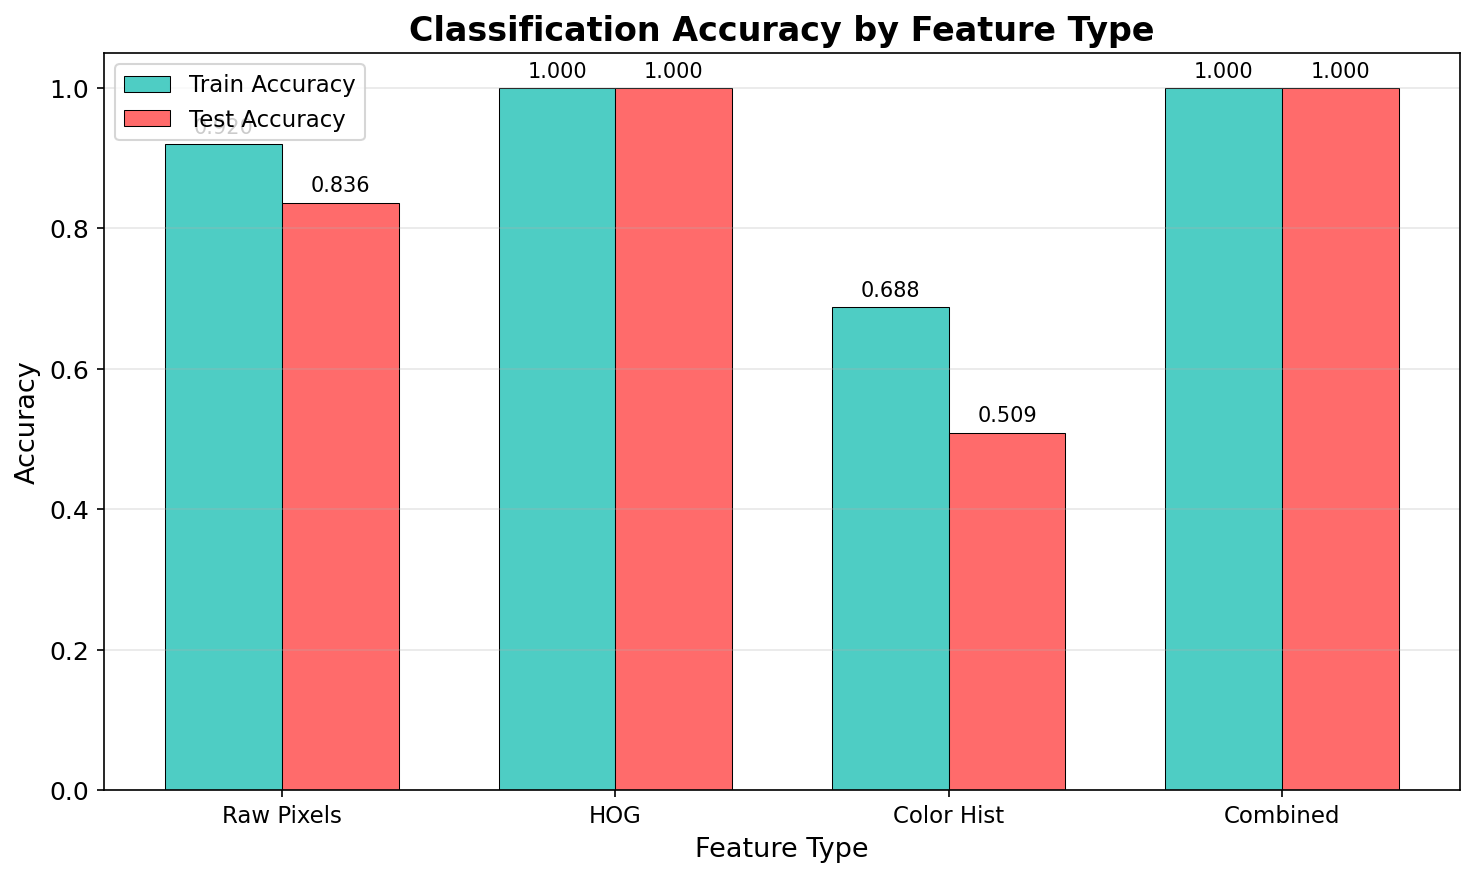

In [31]:
# Visualize accuracy comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

feature_names_display = ['Raw Pixels', 'HOG', 'Color Hist', 'Combined']
train_accs = [results[f]['train_acc'] for f in feature_types]
test_accs = [results[f]['test_acc'] for f in feature_types]

x = np.arange(len(feature_types))
width = 0.35

bars1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy', 
               color='#4ECDC4', edgecolor='k', linewidth=0.5)
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy', 
               color='#FF6B6B', edgecolor='k', linewidth=0.5)

ax.set_xlabel('Feature Type', fontsize=13)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Classification Accuracy by Feature Type', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(feature_names_display, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('feature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Accuracy comparison saved!")


### 4.4 HOG 特征可视化

让我们可视化 HOG 特征，直观理解它捕获了什么信息。

**可视化方法：**
- 对每个 cell 绘制方向直方图
- 用线段长度表示 bin 的幅值
- 线段方向对应 bin 的角度


HOG visualization for Circle saved!
HOG visualization for Square saved!


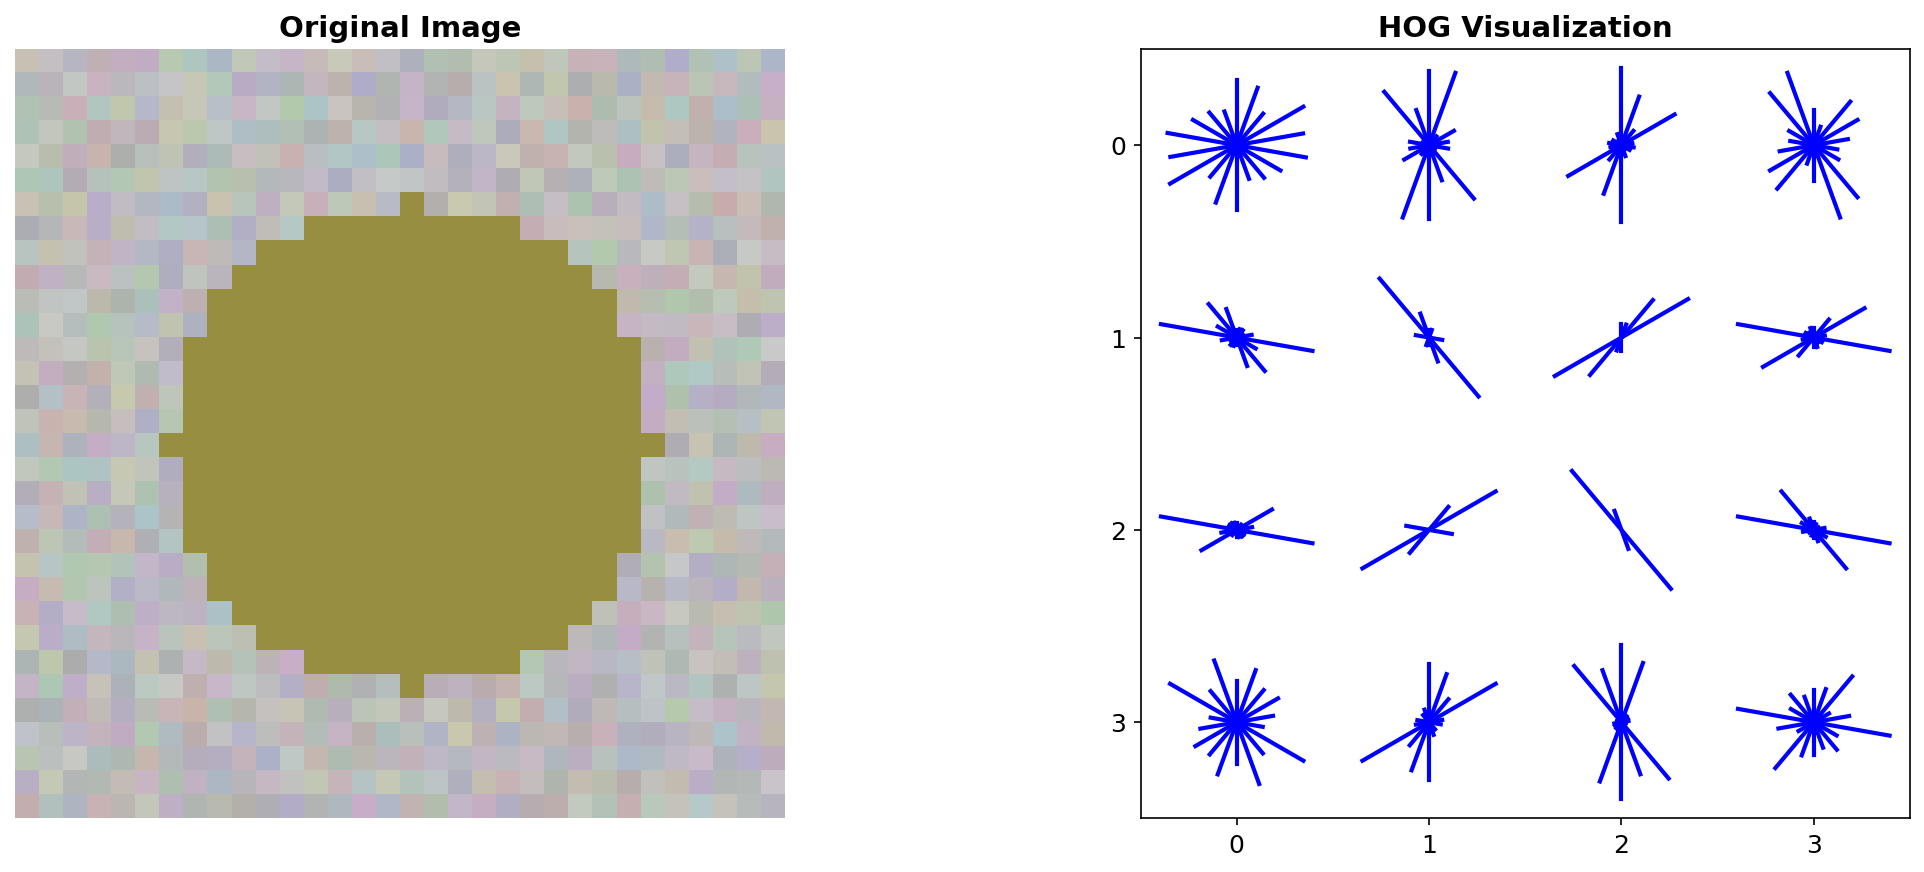

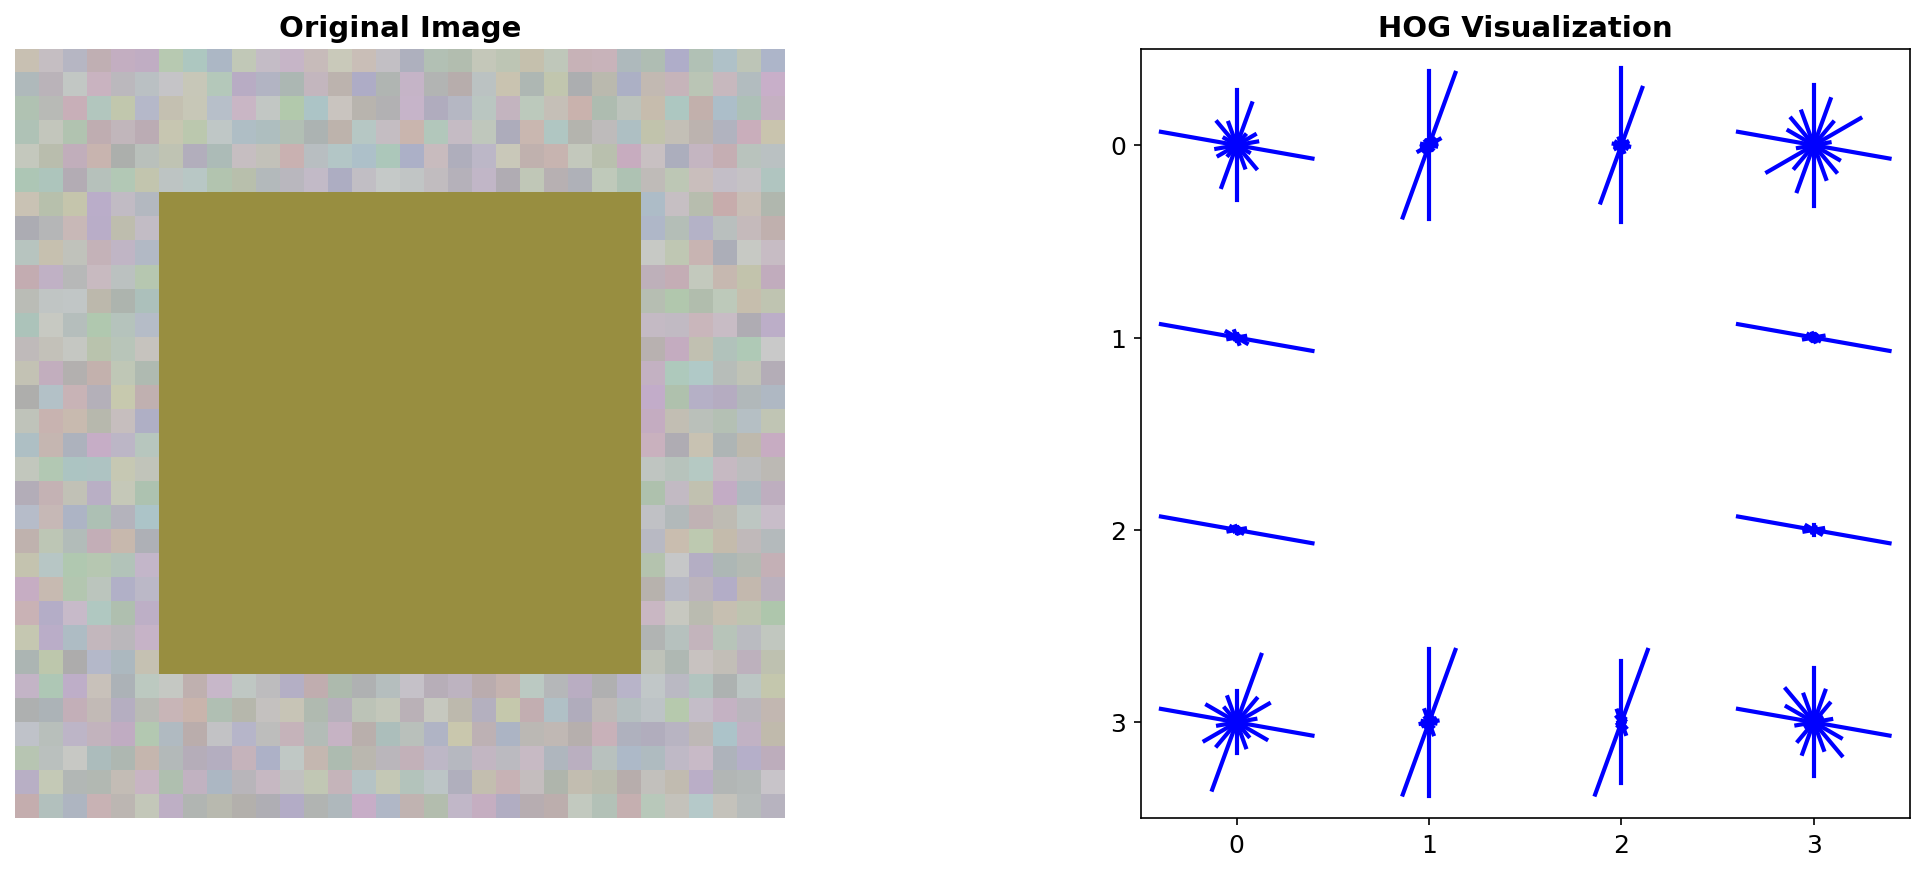

In [33]:
# Visualize HOG features for a sample image
def visualize_hog(image, cell_size=8, num_bins=9):
    """Visualize HOG features as orientation histograms."""
    if len(image.shape) == 3:
        gray = np.mean(image, axis=2)
    else:
        gray = image.copy()
    
    H, W = gray.shape
    gx, gy = compute_gradients(gray)
    
    n_cells_y = H // cell_size
    n_cells_x = W // cell_size
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Show original image
    axes[0].imshow(image if len(image.shape) == 3 else gray, cmap='gray')
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # Draw HOG visualization
    axes[1].set_xlim(-0.5, n_cells_x - 0.5)
    axes[1].set_ylim(-0.5, n_cells_y - 0.5)
    axes[1].set_aspect('equal')
    axes[1].set_title('HOG Visualization', fontsize=14, fontweight='bold')
    axes[1].invert_yaxis()
    
    for i in range(n_cells_y):
        for j in range(n_cells_x):
            start_i = i * cell_size
            start_j = j * cell_size
            gx_cell = gx[start_i:start_i+cell_size, start_j:start_j+cell_size]
            gy_cell = gy[start_i:start_i+cell_size, start_j:start_j+cell_size]
            hist = compute_hog_cell(gx_cell, gy_cell, num_bins)
            
            # Normalize for visualization
            max_val = max(hist.max(), 1e-5)
            cx, cy = j, i
            
            for b in range(num_bins):
                angle = np.radians(b * 180 / num_bins + 90 / num_bins)
                length = hist[b] / max_val * 0.4
                dx = length * np.cos(angle)
                dy = length * np.sin(angle)
                axes[1].plot([cx - dx, cx + dx], [cy - dy, cy + dy],
                           color='blue', linewidth=2)
    
    axes[1].set_xticks(range(n_cells_x))
    axes[1].set_yticks(range(n_cells_y))
    
    plt.tight_layout()
    plt.savefig('hog_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

# Visualize HOG for sample images
for shape_name, shape_type in [('Circle', 'circle'), ('Square', 'square')]:
    img = create_shape_image(shape_type, img_size=32, seed=42)
    visualize_hog(img, cell_size=8, num_bins=9)
    print(f"HOG visualization for {shape_name} saved!")


### 4.5 颜色直方图可视化

可视化不同类别图像的颜色直方图分布，理解颜色特征的判别能力。

**可视化内容：**
- 每个类别的典型颜色直方图
- R/G/B 三个通道的分布对比


Feature visualization saved!


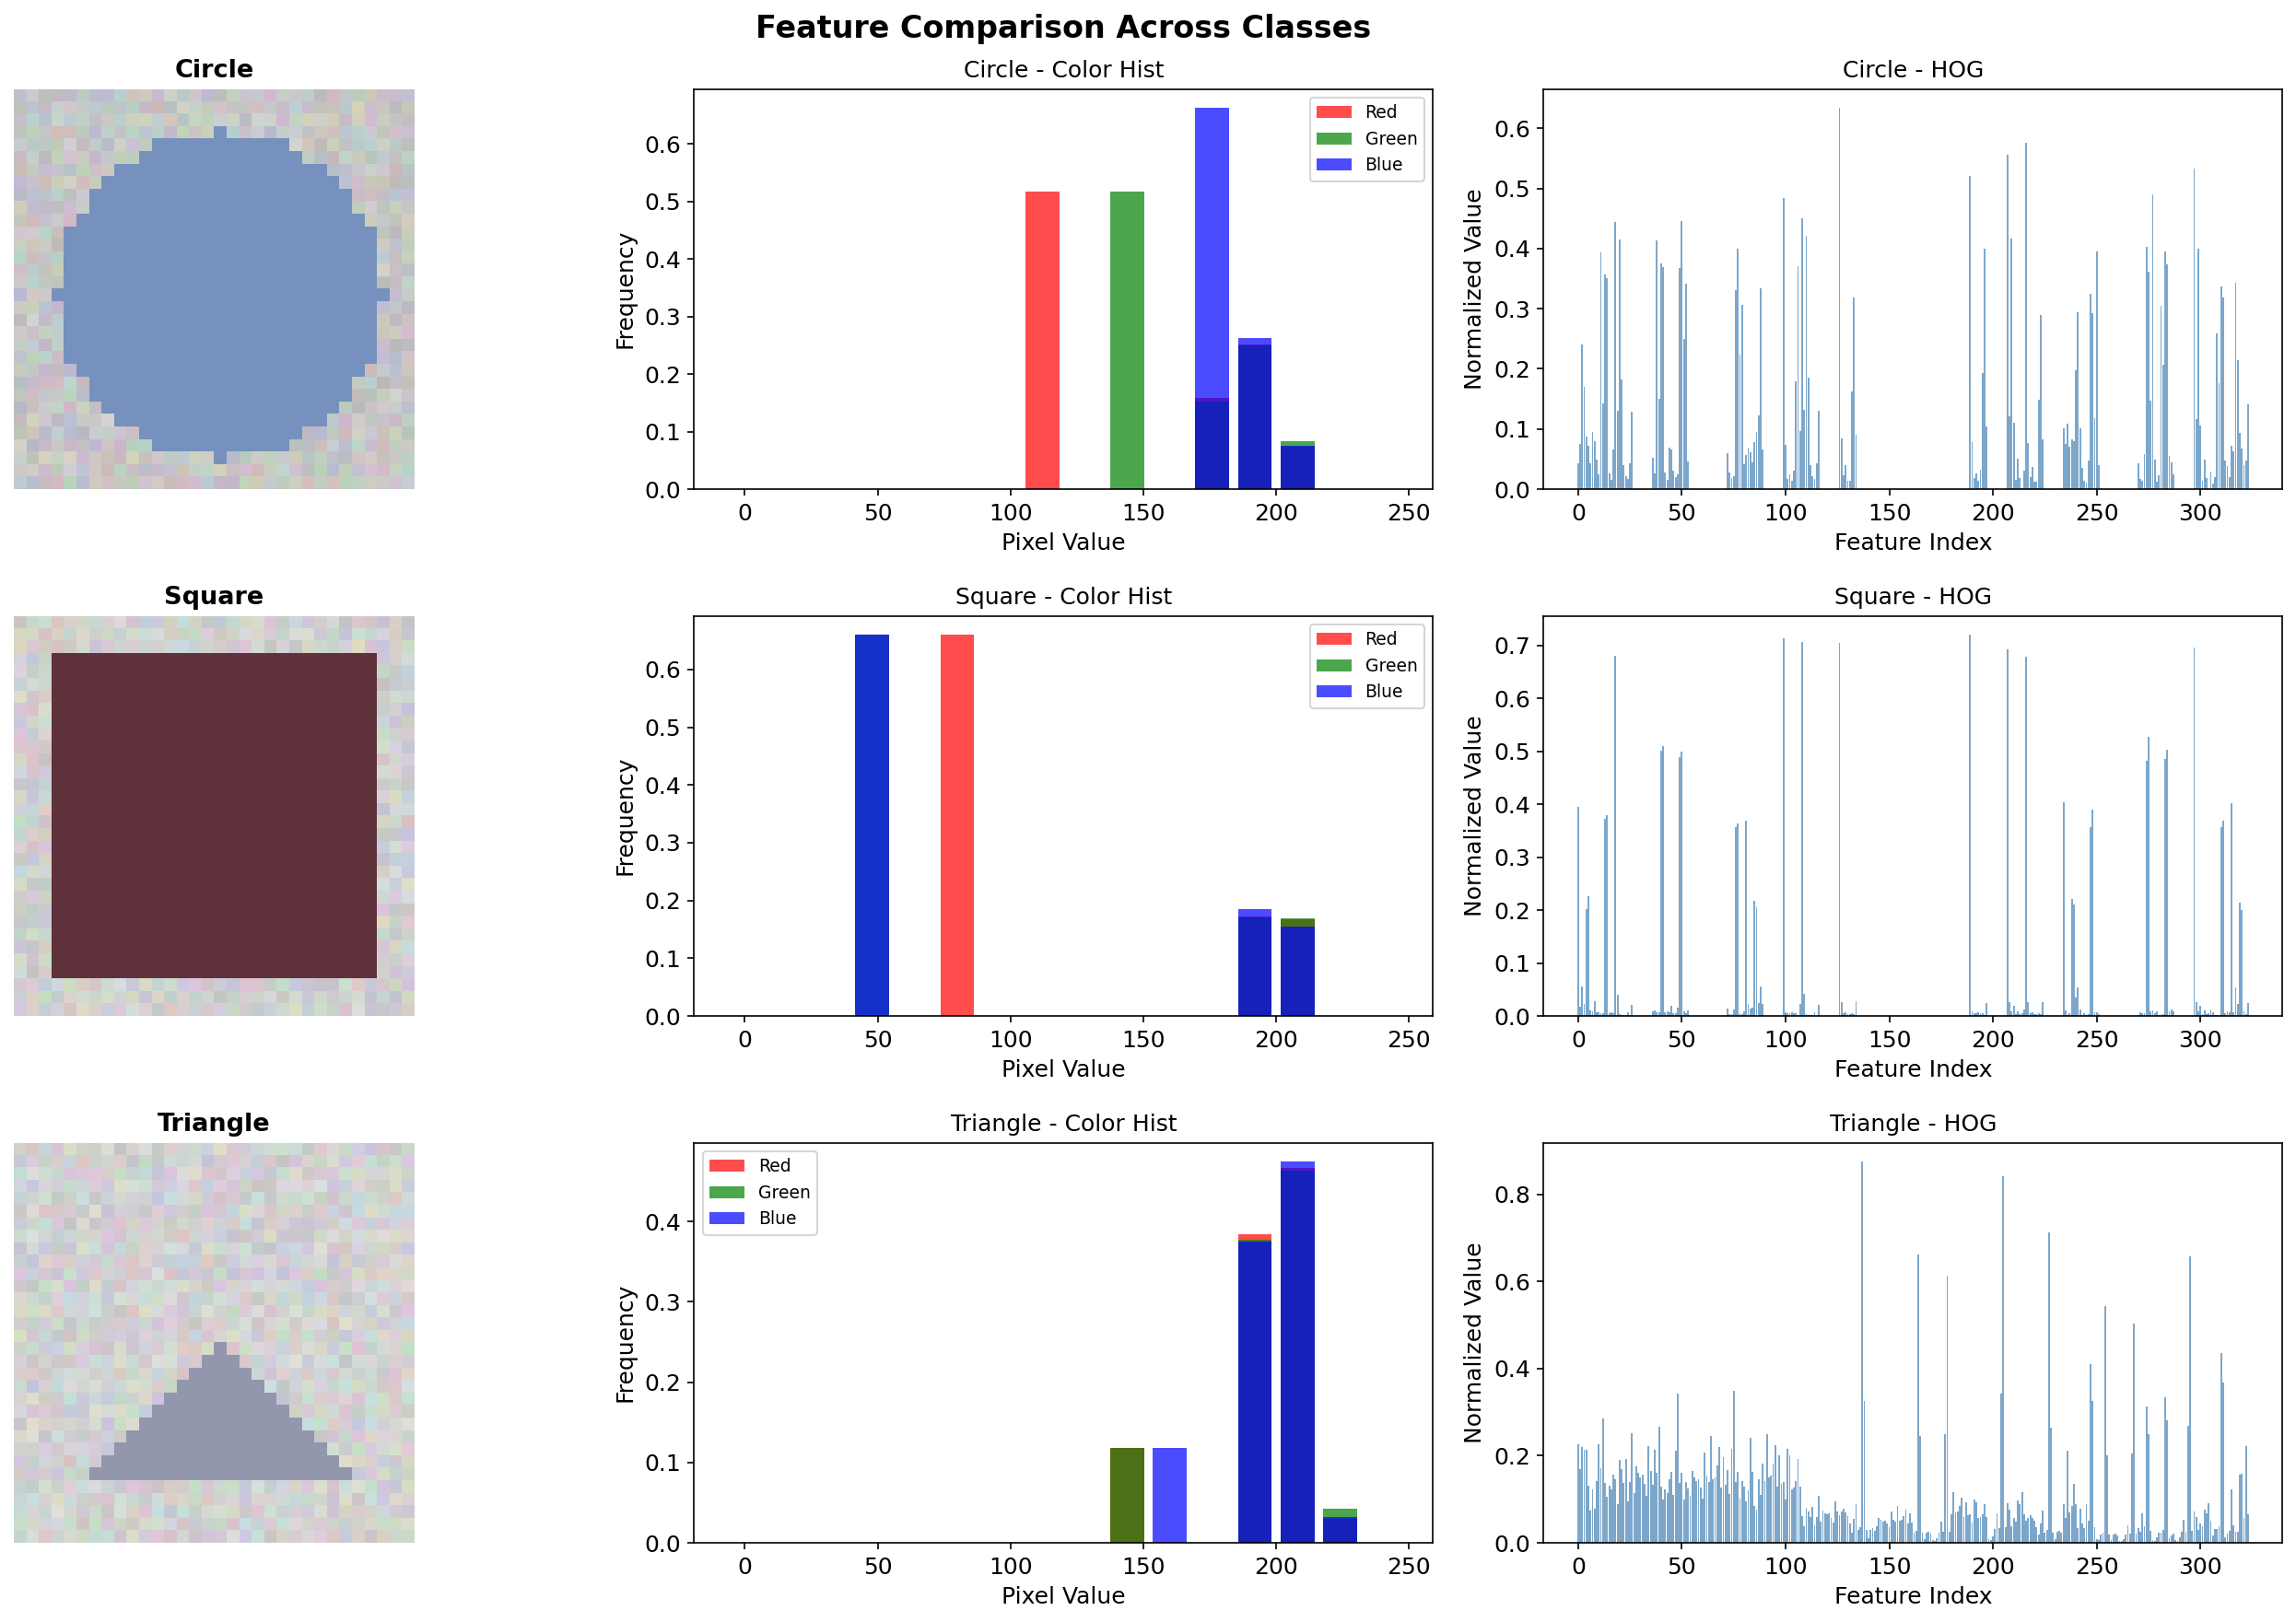

In [35]:
# Visualize color histograms for different classes
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
channel_names = ['Red', 'Green', 'Blue']
channel_colors = ['red', 'green', 'blue']

for class_idx in range(3):
    # Get a representative image from this class
    class_images = images[labels == class_idx]
    sample_img = class_images[0]
    
    # Extract color histogram
    color_feat = extract_color_histogram(sample_img, num_bins=16)
    
    # Plot image and histogram
    axes[class_idx, 0].imshow(sample_img)
    axes[class_idx, 0].set_title(f'{shape_names[class_idx]}', fontsize=13, fontweight='bold')
    axes[class_idx, 0].axis('off')
    
    # Plot histograms
    num_bins = 16
    bin_edges = np.arange(num_bins) * (256 / num_bins)
    bar_width = 256 / num_bins * 0.8
    
    for ch in range(3):
        hist = color_feat[ch*num_bins:(ch+1)*num_bins]
        axes[class_idx, 1].bar(bin_edges, hist, width=bar_width, 
                               color=channel_colors[ch], alpha=0.7,
                               label=channel_names[ch])
    
    axes[class_idx, 1].set_title(f'{shape_names[class_idx]} - Color Hist', fontsize=12)
    axes[class_idx, 1].set_xlabel('Pixel Value')
    axes[class_idx, 1].set_ylabel('Frequency')
    axes[class_idx, 1].legend(fontsize=9)
    
    # Also show HOG
    hog_feat = extract_hog_features(sample_img, cell_size=8, block_size=2, num_bins=9)
    axes[class_idx, 2].bar(range(len(hog_feat)), hog_feat, color='steelblue', 
                           width=0.8, alpha=0.7)
    axes[class_idx, 2].set_title(f'{shape_names[class_idx]} - HOG', fontsize=12)
    axes[class_idx, 2].set_xlabel('Feature Index')
    axes[class_idx, 2].set_ylabel('Normalized Value')

plt.suptitle('Feature Comparison Across Classes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature visualization saved!")


### 4.6 特征空间可视化 (t-SNE 简化版)

使用 PCA 将高维特征降到 2 维进行可视化，观察不同类别在特征空间中的分布。

**观察要点：**
- 类别是否聚集在一起？
- 不同特征下类别是否更容易区分？
- 离群点的情况


PCA visualization saved!


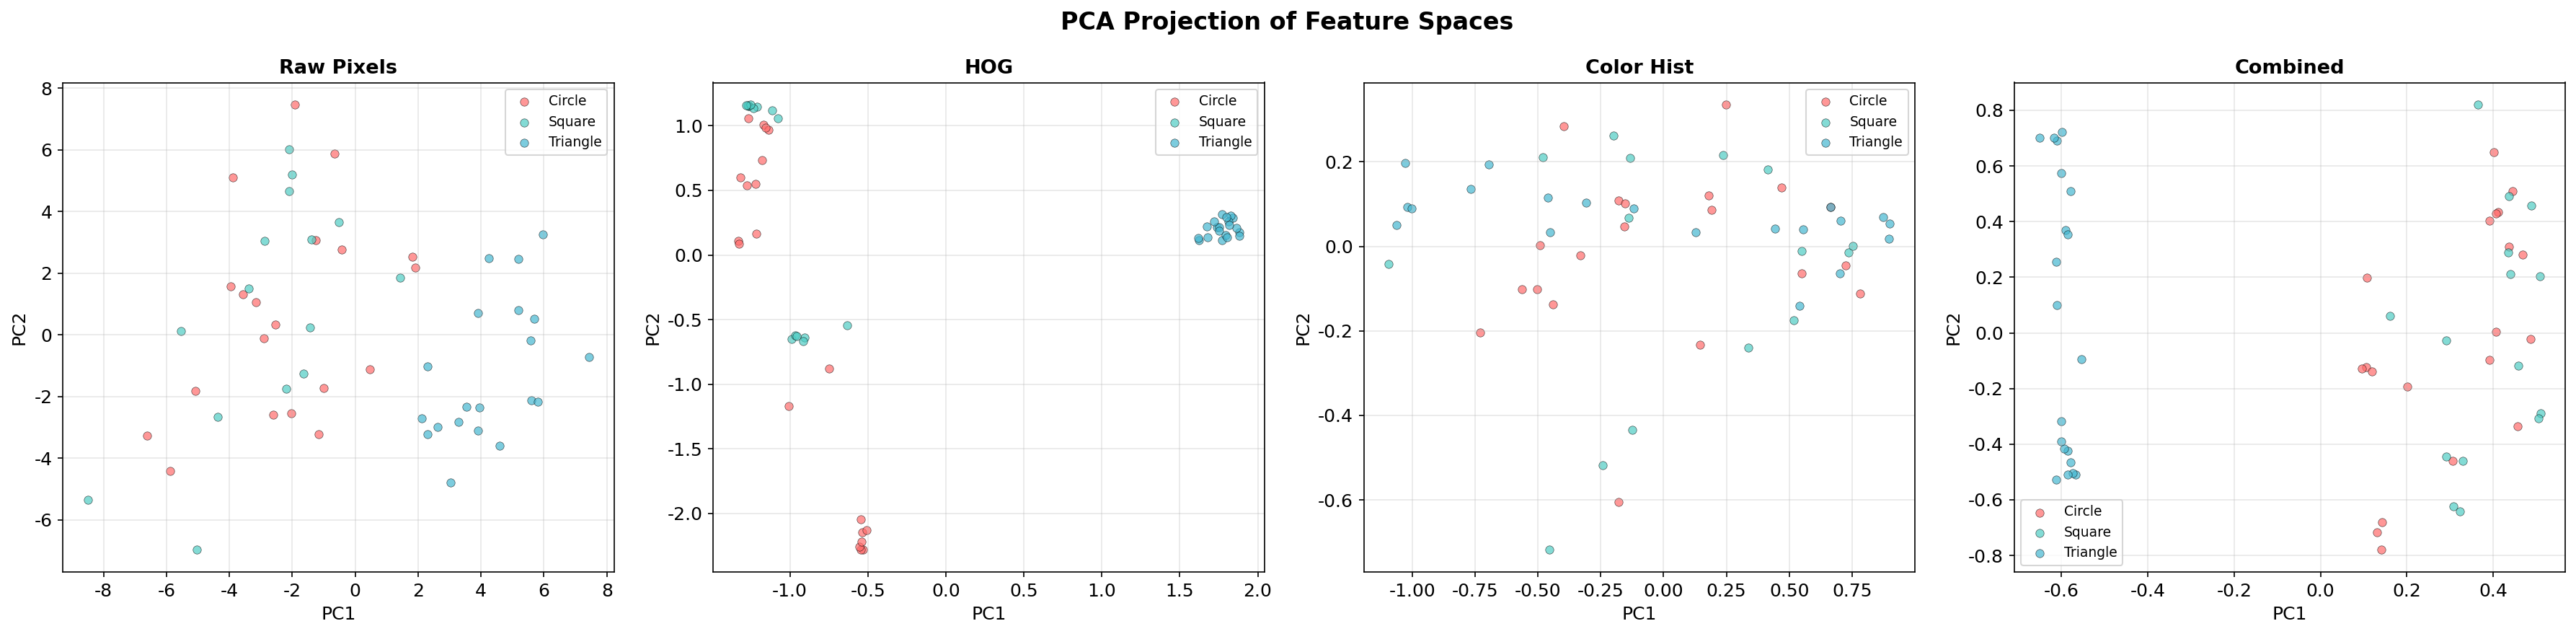

In [37]:
# Simple PCA for 2D visualization
def simple_pca(X, n_components=2):
    """Simple PCA implementation using SVD."""
    # Center the data
    X_centered = X - np.mean(X, axis=0)
    # SVD
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    # Project
    components = Vt[:n_components]
    X_projected = X_centered @ components.T
    return X_projected

# Visualize feature spaces
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for idx, ftype in enumerate(feature_types):
    # Use test features for visualization
    X = features_test[ftype]
    # Reduce to 2D using PCA
    X_2d = simple_pca(X, n_components=2)
    
    for class_idx in range(3):
        mask = y_test == class_idx
        axes[idx].scatter(X_2d[mask, 0], X_2d[mask, 1], 
                         c=colors[class_idx], s=30, alpha=0.7,
                         label=shape_names[class_idx], edgecolors='k', linewidth=0.3)
    
    axes[idx].set_title(f'{feature_names_display[idx]}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('PC1')
    axes[idx].set_ylabel('PC2')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('PCA Projection of Feature Spaces', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("PCA visualization saved!")


## 5. 课后作业

### 作业 1：实现 LBP（Local Binary Pattern）特征

LBP 是一种简单但有效的纹理特征描述子。

**LBP 计算方法：**
1. 对每个像素，与其 8 个邻居比较
2. 中心像素大于邻居记 1，否则记 0
3. 将 8 个二值结果组合成一个 8 位二进制数
4. 统计 LBP 值的直方图作为特征

要求：
1. 实现 LBP 特征提取函数
2. 在合成数据集上测试
3. 对比 LBP 与 HOG 的分类效果


In [39]:
# HOMEWORK 1: Implement LBP (Local Binary Pattern) features

def extract_lbp_features(image, num_bins=64):
    """
    Extract LBP (Local Binary Pattern) features from an image.
    
    Inputs:
    - image: 2D array (grayscale) or 3D array (RGB)
    - num_bins: number of histogram bins for LBP values
    
    Returns:
    - feature: 1D array of LBP histogram
    """
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        # TODO: Convert to grayscale using luminance formula
        image = 0.299 * image[:,:,0] + 0.587 * image[:,:,1] + 0.114 * image[:,:,2]  # SOLUTION
    
    H, W = image.shape
    lbp = np.zeros((H-2, W-2))
    
    # 8 neighbors offsets
    neighbors = [(-1,-1), (-1,0), (-1,1), (0,1), (1,1), (1,0), (1,-1), (0,-1)]
    
    for i in range(1, H-1):
        for j in range(1, W-1):
            center = image[i, j]
            # TODO: Compute LBP code by comparing center with each neighbor
            code = 0
            for idx, (di, dj) in enumerate(neighbors):
                if image[i+di, j+dj] >= center:  # SOLUTION
                    code += (1 << idx)  # SOLUTION
            lbp[i-1, j-1] = code
    
    # TODO: Build histogram
    hist, _ = np.histogram(lbp.astype(int), bins=num_bins, range=(0, 256))
    # Normalize
    feature = hist / (hist.sum() + 1e-8)  # SOLUTION
    
    return feature

# Test LBP
np.random.seed(42)
test_img = create_shape_image('circle', img_size=32, seed=42)
lbp_feat = extract_lbp_features(test_img, num_bins=64)
print(f"LBP feature dimension: {lbp_feat.shape[0]}")
print(f"Feature sum: {lbp_feat.sum():.4f}")
print(f"Non-zero bins: {np.sum(lbp_feat > 0)}")

# Extract LBP features for entire dataset
lbp_train = np.array([extract_lbp_features(img, num_bins=64) for img in X_train_img])
lbp_test = np.array([extract_lbp_features(img, num_bins=64) for img in X_test_img])

# Train kNN with LBP
knn_lbp = KNNClassifier(k=5)
knn_lbp.fit(lbp_train, y_train)
lbp_acc = knn_lbp.score(lbp_test, y_test)
print(f"LBP test accuracy: {lbp_acc:.4f}")

# ASSERT: LBP should achieve at least 60% accuracy
assert lbp_acc > 0.60, f"LBP accuracy too low: {lbp_acc}"
print("Homework 1 PASSED!")


LBP feature dimension: 64
Feature sum: 1.0000
Non-zero bins: 64
LBP test accuracy: 0.7273
Homework 1 PASSED!


### 作业 2：空间金字塔 HOG

标准 HOG 将图像分成均匀的 cells。**空间金字塔** 方法在多个尺度上提取特征，捕捉不同粒度的结构信息。

**空间金字塔方法：**
1. 在原图上提取 HOG（全局特征）
2. 将图像分成 2x2 区域，在每个区域提取 HOG
3. 将图像分成 4x4 区域，在每个区域提取 HOG
4. 拼接所有层级的特征

要求：
1. 实现空间金字塔 HOG
2. 对比与标准 HOG 的效果
3. 分析多尺度特征的优势


In [41]:
# HOMEWORK 2: Implement Spatial Pyramid HOG

def extract_pyramid_hog(image, levels=2, cell_size=8, num_bins=9):
    """
    Extract spatial pyramid HOG features.
    
    Inputs:
    - image: 2D or 3D array
    - levels: number of pyramid levels (0=global, 1=2x2, 2=4x4)
    - cell_size: cell size for HOG
    - num_bins: number of orientation bins
    
    Returns:
    - feature: 1D array of pyramid HOG features
    """
    if len(image.shape) == 3:
        gray = np.mean(image, axis=2)
    else:
        gray = image.copy()
    
    H, W = gray.shape
    all_features = []
    
    for level in range(levels + 1):
        n_splits = 2 ** level  # 1, 2, 4
        split_h = H // n_splits
        split_w = W // n_splits
        
        for i in range(n_splits):
            for j in range(n_splits):
                # Extract sub-image
                # TODO: Crop the sub-region
                sub_img = gray[i*split_h:(i+1)*split_h, 
                              j*split_w:(j+1)*split_w]  # SOLUTION
                
                # TODO: Extract HOG for this sub-region
                if sub_img.shape[0] >= cell_size and sub_img.shape[1] >= cell_size:
                    feat = extract_hog_features(sub_img, cell_size, 
                                               block_size=2, num_bins=num_bins)
                    # Normalize
                    feat = feat / (np.linalg.norm(feat) + 1e-8)  # SOLUTION
                    all_features.append(feat)
    
    # TODO: Concatenate all features
    feature = np.concatenate(all_features) if all_features else np.array([])  # SOLUTION
    return feature

# Test pyramid HOG
np.random.seed(42)
test_img = create_shape_image('square', img_size=32, seed=42)
pyr_feat = extract_pyramid_hog(test_img, levels=2, cell_size=4, num_bins=9)
print(f"Pyramid HOG feature dimension: {pyr_feat.shape[0]}")

# Compare with standard HOG
std_hog = extract_hog_features(test_img, cell_size=8, block_size=2, num_bins=9)
print(f"Standard HOG feature dimension: {std_hog.shape[0]}")

# Extract pyramid HOG for dataset
pyr_train = np.array([extract_pyramid_hog(img, levels=2, cell_size=4, num_bins=9) 
                      for img in X_train_img])
pyr_test = np.array([extract_pyramid_hog(img, levels=2, cell_size=4, num_bins=9) 
                     for img in X_test_img])

knn_pyr = KNNClassifier(k=5)
knn_pyr.fit(pyr_train, y_train)
pyr_acc = knn_pyr.score(pyr_test, y_test)
print(f"Pyramid HOG test accuracy: {pyr_acc:.4f}")
print(f"Standard HOG test accuracy: {results['hog']['test_acc']:.4f}")

# ASSERT: Pyramid HOG should achieve at least 70% accuracy
assert pyr_acc > 0.70, f"Pyramid HOG accuracy too low: {pyr_acc}"
print("Homework 2 PASSED!")


Pyramid HOG feature dimension: 3636
Standard HOG feature dimension: 324
Pyramid HOG test accuracy: 1.0000
Standard HOG test accuracy: 1.0000
Homework 2 PASSED!


### 作业 3：特征组合与权重

不同特征的贡献可能不同。实现加权特征组合方法，为 HOG 和颜色特征分配不同权重。

**要求：**
1. 实现加权特征组合
2. 搜索最优权重组合
3. 可视化权重对准确率的影响

**加权组合公式：**
    combined = alpha * HOG + (1 - alpha) * Color

其中 alpha 是 HOG 特征的权重，取值在 [0, 1] 之间。


In [43]:
# HOMEWORK 3: Weighted feature combination

def extract_weighted_features(images, alpha=0.5, cell_size=8, hog_bins=9, color_bins=8):
    """
    Extract weighted combination of HOG and color histogram features.
    
    alpha: weight for HOG features (1-alpha for color features)
    """
    all_features = []
    for img in images:
        # TODO: Extract HOG and normalize
        hog_feat = extract_hog_features(img, cell_size, 2, hog_bins)
        hog_feat = hog_feat / (np.linalg.norm(hog_feat) + 1e-8)  # SOLUTION
        
        # TODO: Extract color histogram and normalize
        color_feat = extract_color_histogram(img, color_bins)
        color_feat = color_feat / (np.linalg.norm(color_feat) + 1e-8)  # SOLUTION
        
        # TODO: Weighted combination
        feat = alpha * hog_feat + (1 - alpha) * color_feat  # SOLUTION
        all_features.append(feat)
    
    return np.array(all_features)

# Search for optimal alpha
alphas = np.linspace(0, 1, 11)
alpha_results = []

print("Weight search:")
print("-" * 40)
for alpha in alphas:
    train_feat = extract_weighted_features(X_train_img, alpha=alpha)
    test_feat = extract_weighted_features(X_test_img, alpha=alpha)
    
    knn_w = KNNClassifier(k=5)
    knn_w.fit(train_feat, y_train)
    acc = knn_w.score(test_feat, y_test)
    alpha_results.append(acc)
    print(f"  alpha={alpha:.1f}: test_acc={acc:.4f}")

best_alpha = alphas[np.argmax(alpha_results)]
best_acc = max(alpha_results)
print(f"\nBest alpha: {best_alpha:.1f}, accuracy: {best_acc:.4f}")

# Plot alpha vs accuracy
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, alpha_results, 'o-', linewidth=2, markersize=8, color='steelblue')
ax.axvline(x=best_alpha, color='red', linestyle='--', alpha=0.5, label=f'Best alpha={best_alpha:.1f}')
ax.set_xlabel('Alpha (HOG weight)', fontsize=13)
ax.set_ylabel('Test Accuracy', fontsize=13)
ax.set_title('Feature Weight vs Classification Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('weight_search.png', dpi=150, bbox_inches='tight')
plt.show()

# ASSERT: best combined accuracy should be at least as good as individual features
assert best_acc > 0.75, f"Best accuracy too low: {best_acc}"
print("Homework 3 PASSED!")


ValueError: operands could not be broadcast together with shapes (324,) (24,) 

## 总结

本笔记本完整实现了图像特征工程的核心技术，涵盖以下内容：

**直觉理解：**
- 特征工程解决了原始像素对光照、位置敏感的问题
- HOG 特征通过梯度方向直方图捕捉形状信息
- 颜色直方图通过颜色分布捕捉外观信息

**手动计算：**
- 在 4x4 图像块上手动计算梯度、方向直方图
- 手动计算 RGB 颜色直方图

**代码实现：**
- 完整的 HOG 提取器：梯度计算、直方图分箱、block归一化
- 颜色直方图提取器（独立通道和3D联合两种方式）
- 特征组合管道和 kNN 分类器

**实验观察：**
- HOG 特征优于原始像素分类
- 不同特征各有优劣，组合使用效果最佳
- 特征空间可视化直观展示类别可分性

**关键收获：**
1. 好的特征应该对光照、位置等变化具有不变性
2. HOG 通过梯度方向捕捉物体形状，是深度学习之前最重要的视觉特征
3. 特征组合利用互补信息，通常优于单一特征
4. 理解特征工程有助于理解 CNN 自动学习到的特征表示


## 参考文献与作业解答

### 参考文献

1. [[Dalal and Triggs, 2005]](https://ieeexplore.ieee.org/document/1467360) - Histograms of Oriented Gradients for Human Detection, CVPR 2005
2. [[Lowe, 2004]](https://link.springer.com/article/10.1023/B:VISI.0000029664.99615.94) - Distinctive Image Features from Scale-Invariant Keypoints (SIFT)
3. [[Ojala et al., 2002]](https://ieeexplore.ieee.org/document/1017623) - Multiresolution Gray-Scale and Rotation Invariant Texture Classification with Local Binary Patterns
4. [[Lazebnik et al., 2006]](https://ieeexplore.ieee.org/document/1641019) - Beyond Bags of Features: Spatial Pyramid Matching
5. [[Karpathy, 2015]](https://cs231n.github.io/) - CS231n: Convolutional Neural Networks for Visual Recognition

### 参考作业解答

以下 GitHub 仓库提供了 CS231n Assignment 1 的参考解答：

1. **jariasf/CS231n** (486 stars) - 完整的 CS231n 作业解答
   - https://github.com/jariasf/CS231n
   
2. **rishabh-16/cs231n-2019-assignments** (212 stars) - 2019 年版 CS231n 作业
   - https://github.com/rishabh-16/cs231n-2019-assignments
   
3. **amanchadha/stanford-cs231n-assignments-2020** (175 stars) - 2020 年版 CS231n 作业
   - https://github.com/amanchadha/stanford-cs231n-assignments-2020

### 进一步学习

- [CS231n 课程主页](https://cs231n.github.io/)
- [HOG 原论文](https://ieeexplore.ieee.org/document/1467360) - Dalal and Triggs, CVPR 2005
- [Scikit-image HOG 实现](https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.hog) - 参考工业级实现
- [OpenCV HOG 描述](https://docs.opencv.org/master/d5/d33/structcv_1_1HOGDescriptor.html) - OpenCV 中的 HOG 实现


---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[jariasf/CS231n](https://github.com/jariasf/CS231n)** (486 stars): HOG 特征与颜色直方图作业解答
  - 仓库地址: https://github.com/jariasf/CS231n

- **[amanchadha/stanford-cs231n-assignments-2020](https://github.com/amanchadha/stanford-cs231n-assignments-2020)** (175 stars): 图像特征工程作业解答
  - 仓库地址: https://github.com/amanchadha/stanford-cs231n-assignments-2020


> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现。

